# Geom-Fast Node-Count Convergence Analysis

Compares the **geometric ray-fan CFW** at a sweep of Gauss–Legendre pupil node counts
$N \in \{5,10,16,20,24,28,32,36,40\}$ against the **FFT-PSF CFW** treated as ground truth.

| File | Role |
|------|------|
| `cfw_fft_defocus.csv` | ground truth (FFT diffraction PSF), 50 µm z grid |
| `cfw_geom_nodes_defocus.csv` | geom-fast at every node count, 10 µm z grid |

**Goal:** find the smallest $N$ at which the geom-fast CFW curve has converged — i.e. its
error against the FFT reference stops decreasing — and recommend a node count to use.

The limiting metric is the **per-exposure maximum single-point error** in the transition
zones, not the mean (which dilutes localized spikes). Exposures 1 and 2 are all-zero in
both datasets and are dropped automatically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GEOM_CSV = "cfw_defocus_data/cfw_geom_nodes_defocus.csv"
FFT_CSV  = "cfw_defocus_data/cfw_fft_defocus.csv"

geom = pd.read_csv(GEOM_CSV).set_index("z_um")
fft  = pd.read_csv(FFT_CSV).set_index("z_um")

# Node counts present in the geom sweep
NODES = sorted({int(c.split("geom")[1].split("_")[0])
                for c in geom.columns if c.startswith("cfw_geom")})

# Common z grid (FFT is the coarser 50 µm grid -> defines the comparison points)
ZC = geom.index.intersection(fft.index)

# Keep only exposures that are non-trivial in either dataset
ALL_EXP = [1, 2, 4, 8, 16]
EXPS = [e for e in ALL_EXP
        if fft[f"cfw_exp_{e}_um"].abs().sum()
        or geom.filter(like=f"_exp_{e}_um").abs().to_numpy().sum()]

print(f"node counts      : {NODES}")
print(f"common z points  : {len(ZC)}  ({ZC.min():.0f} .. {ZC.max():.0f} µm, step "
      f"{int(np.diff(np.sort(ZC.values)).min())} µm)")
print(f"non-trivial exp  : {EXPS}   (exp 1 & 2 are all-zero -> dropped)")

node counts      : [5, 10, 16, 20, 24, 28, 32, 36, 40]
common z points  : 29  (-700 .. 700 µm, step 50 µm)
non-trivial exp  : [4, 8, 16]   (exp 1 & 2 are all-zero -> dropped)


## 1. Error vs FFT ground truth

For each node count $N$ and exposure $e$, on the common z grid:

$$\mathrm{MAD}(N,e) = \frac{1}{|Z|}\sum_z \big|\,\mathrm{CFW}^{geom}_{N,e}(z) - \mathrm{CFW}^{fft}_{e}(z)\,\big|,
\qquad
\mathrm{MAX}(N,e) = \max_z \big|\,\cdot\,\big|$$

In [2]:
mad = pd.DataFrame(index=NODES, columns=EXPS, dtype=float)
mx  = pd.DataFrame(index=NODES, columns=EXPS, dtype=float)

for n in NODES:
    for e in EXPS:
        g  = geom.loc[ZC, f"cfw_geom{n}_exp_{e}_um"].to_numpy(float)
        gt = fft.loc[ZC,  f"cfw_exp_{e}_um"].to_numpy(float)
        d  = np.abs(g - gt)
        mad.loc[n, e] = d.mean()
        mx.loc[n, e]  = d.max()

mad.index.name = mx.index.name = "N"
mad["mean"]  = mad[EXPS].mean(axis=1)
mx["worst"]  = mx[EXPS].max(axis=1)

print("=== MAD vs FFT (mean |Δ|, µm) ===")
display(mad.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r", subset=["mean"]))

print("=== MAX single-point error vs FFT (µm) ===")
display(mx.astype({**{e: int for e in EXPS}, "worst": int})
          .style.background_gradient(cmap="RdYlGn_r", subset=["worst"]))

=== MAD vs FFT (mean |Δ|, µm) ===


,4,8,16,mean
N,,,,
5,2.41,7.48,8.55,6.15
10,0.34,1.66,2.10,1.37
16,0.28,1.14,0.83,0.75
20,0.28,0.66,0.72,0.55
24,0.24,0.55,0.62,0.47
28,0.28,0.52,0.59,0.46
32,0.17,0.62,0.41,0.40
36,0.14,0.52,0.52,0.39
40,0.14,0.66,0.55,0.45


=== MAX single-point error vs FFT (µm) ===


,4,8,16,worst
N,,,,
5,14,22,30,30
10,2,16,12,16
16,2,8,3,8
20,3,4,3,4
24,2,2,3,3
28,3,2,2,3
32,2,3,2,3
36,2,2,2,2
40,2,6,3,6


## 2. Convergence curves

Left: mean abs error. Right: worst single-point error (the metric that decides convergence).
A horizontal guide marks the **~3 µm error floor** — the residual set by integer-pixel CFW
quantization and the FFT reference's own 50 µm sampling, below which no node count can go.

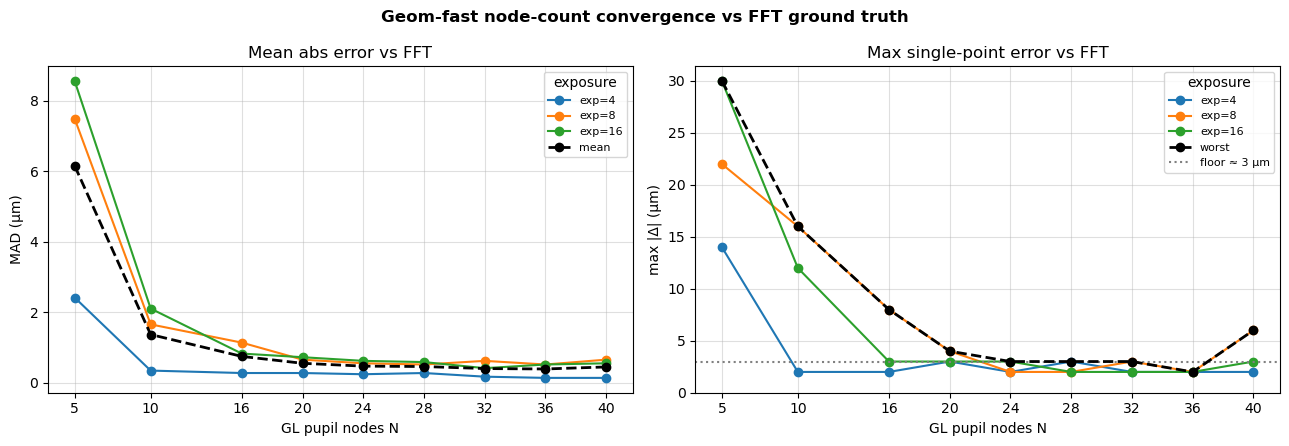

In [3]:
FLOOR = 3.0   # µm, quantization / reference-precision floor

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for e in EXPS:
    axL.plot(NODES, mad[e], "o-", label=f"exp={e}")
    axR.plot(NODES, mx[e],  "o-", label=f"exp={e}")

axL.plot(NODES, mad["mean"], "k--o", lw=2, label="mean", zorder=5)
axR.plot(NODES, mx["worst"], "k--o", lw=2, label="worst", zorder=5)
axR.axhline(FLOOR, color="grey", ls=":", lw=1.5, label=f"floor ≈ {FLOOR:.0f} µm")

for ax, t, yl in ((axL, "Mean abs error vs FFT", "MAD (µm)"),
                  (axR, "Max single-point error vs FFT", "max |Δ| (µm)")):
    ax.set(title=t, xlabel="GL pupil nodes N", ylabel=yl)
    ax.set_xticks(NODES)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8, title="exposure")
axR.set_ylim(0, None)

plt.suptitle("Geom-fast node-count convergence vs FFT ground truth", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Incremental improvement & convergence point

Convergence = the worst-case error stops decreasing as $N$ grows. We track the change in
worst max-error between consecutive node counts; once it flattens at the floor, adding
nodes is wasted compute (and can even regress due to node/fringe beating).

In [4]:
worst = mx["worst"]
tbl = pd.DataFrame({"worst_max_err": worst.astype(int)})
tbl["Δ_vs_prev"] = worst.diff().fillna(0).astype(int)
tbl["mean_MAD"]  = mad["mean"].round(2)
tbl["at_floor"]  = worst <= FLOOR
display(tbl)

# Smallest N that reaches the floor; median over remaining N makes this robust to
# the isolated high-N regression (node/fringe beating) instead of letting it veto.
conv = next((n for n in NODES
             if mx.loc[n, "worst"] <= FLOOR
             and np.median([mx.loc[m, "worst"] for m in NODES if m >= n]) <= FLOOR), None)
print(f"Smallest N at the {FLOOR:.0f} µm floor (robust to high-N beating): N = {conv}")

,worst_max_err,Δ_vs_prev,mean_MAD,at_floor
N,,,,
5,30,0,6.15,False
10,16,-14,1.37,False
16,8,-8,0.75,False
20,4,-4,0.55,False
24,3,-1,0.47,True
28,3,0,0.46,True
32,3,0,0.40,True
36,2,-1,0.39,True
40,6,4,0.45,False


Smallest N at the 3 µm floor (robust to high-N beating): N = 24


## 4. Where the residual error lives

The biggest geom-vs-FFT discrepancies sit in the through-focus **transition zones**
(where CFW rises/falls steeply). Below we list, per node count, the single worst point and
the exposure / defocus at which it occurs.

In [5]:
rows = []
for n in NODES:
    best = None
    for e in EXPS:
        g  = geom.loc[ZC, f"cfw_geom{n}_exp_{e}_um"].to_numpy(float)
        gt = fft.loc[ZC,  f"cfw_exp_{e}_um"].to_numpy(float)
        d  = np.abs(g - gt); i = int(d.argmax())
        if best is None or d[i] > best[0]:
            best = (d[i], e, float(ZC[i]), g[i], gt[i])
    rows.append((n, *best))

worst_df = pd.DataFrame(rows, columns=["N", "max|Δ|", "exp", "z_um", "geom", "fft"])
worst_df = worst_df.astype({"max|Δ|": int, "exp": int, "z_um": int, "geom": int, "fft": int})
display(worst_df.set_index("N"))

,max|Δ|,exp,z_um,geom,fft
N,,,,,
5,30,16,650,64,34
10,16,8,350,28,12
16,8,8,350,20,12
20,4,8,300,17,21
24,3,16,700,29,32
28,3,4,-150,13,16
32,3,8,300,18,21
36,2,4,-150,14,16
40,6,8,350,6,12


## 5. Conclusion

- **N = 5 is unusable** (worst error ~30 µm). N = 10 still misses the exp=8 transition by ~16 µm.
- The worst-case error **halves per step from 5→10→16→20** (30 → 16 → 8 → 4), then flattens
  into a **~2–3 µm floor from N ≈ 24 onward**. That floor is integer-pixel CFW quantization
  plus the FFT reference's own 50 µm z sampling — not a convergence failure.
- **Non-monotonic tail:** very high node counts (e.g. N = 40) can *regress* at isolated points
  due to quadrature-node / fringe beating, so "more nodes" is not strictly better.
- The limiting exposure is **exp = 8**, whose +350 µm transition spike needs **N ≥ 20** to resolve.

**Recommendation: use N = 24** — the smallest node count that reaches the error floor and stays
there. N = 20 is an acceptable budget option (worst ≈ 4 µm). The current default **N = 32 is
safe but over-sampled** (no accuracy gain over 24); **N ≥ 36 buys nothing** and 40 can be worse.